# Imports

In [2]:
import sys
!{sys.executable} -m pip install --quiet matplotlib geopy scipy scikit-learn
print(sys.executable)
!{sys.executable} -m pip uninstall -y numpy scipy
!{sys.executable} -m pip install --no-cache-dir "numpy>=1.26.4,<2.7" "scipy>=1.17,<1.18"
import sys
!{sys.executable} -m pip install matplotlib

/Users/allandakriener/opt/anaconda3/envs/hdda-hw2/bin/python
Found existing installation: numpy 2.3.5
Uninstalling numpy-2.3.5:
  Successfully uninstalled numpy-2.3.5
Found existing installation: scipy 1.17.0
Uninstalling scipy-1.17.0:
  Successfully uninstalled scipy-1.17.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 34.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.7/22.7 MB 20.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scipy]32m1/2 [scipy]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.63.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import scipy
import ast
import json
import zipfile
import matplotlib.pyplot as plt
from geopy.distance import distance
from pathlib import Path
from scipy.spatial import cKDTree
from datetime import datetime, timedelta
from collections import defaultdict
from sklearn.cluster import DBSCAN

# Thresholds

In [21]:
#Tunable input parameters
WALK_RADIUS_MI = 0.33
# Maximum walk distance (mi) to a stop for it to be considered "nearby"
# 530 m ≈ 6-7 minutes walking at average pace
# Increase if in walkable corridors

TIME_WINDOW_MINUTES = 30
# How many minutes either side of the user's typical departure time we'll consider a transit departure "aligned"
# ±30 min = 1-hour window total. Wider = more options, less precision

WALK_SPEED_MI_H = 3.0
# Average walking speed in mi/h 
# Used to estimate walk time from distance

AVG_DRIVE_SPEED_MI_H = 23.0
# Average driving speed in Atlanta (mi/h) used to estimate drive time
# for comparison. The simulation uses 30; using 23 to
# account for city traffic

MAX_TRANSFERS = 1
# Maximum number of transfers (route changes) to allow in a transit option
# 0 = direct only, 1 = one connection. 

TOP_N_TRANSIT = 2
# Number of transit alternatives to return per recurring trip.
# Showing 2 options (e.g. direct bus + rail option)

## IS THIS HOW WE DID IT THO??? OR ARE WE ALLOWING ONE OFFS ?? ##
MIN_TRIP_OCCURRENCES = 3
# Same value as in the carpool matching notebook
# A trip must recur at least this many times to be eligible for suggestions
# This prevents surfacing transit options for one-off errands

# CO2 emission factors
CO2_DRIVE_LB_PER_MI  = 0.745079   # Average US passenger car: (~0.21 kg/km) 
CO2_BUS_LB_PER_MI    = 0.31577166  # MARTA bus per passenger: (~0.089 kg/km) 
CO2_RAIL_LB_PER_MI   = 0.14546784  # MARTA rail per passenger: (~0.041 kg/km) 
# Sources: EPA (2023), MARTA sustainability reports

#For matching algorithm
#max distance away for DBSCAN clsuter
DBSCAN_BUFFER_MILES = 1
#min number of trips for DBSCAN cluster
DBSCAN_MIN_SAMPLES = 2

print('Configuration loaded.')
print(f'Walk radius: {WALK_RADIUS_MI} mi')
print(f'Time window: ±{TIME_WINDOW_MINUTES} min')
print(f'Max transfers: {MAX_TRANSFERS}')
print(f'Min trip occurrences: {MIN_TRIP_OCCURRENCES}')
print(f'Results per trip: {TOP_N_TRANSIT}')

Configuration loaded.
Walk radius: 0.33 mi
Time window: ±30 min
Max transfers: 1
Min trip occurrences: 3
Results per trip: 2


# Read In Data

In [8]:
#GTFS data
calendar_dates = pd.read_csv('/Users/allandakriener/Desktop/MARTA/calendar_dates.txt')
calendar = pd.read_csv('/Users/allandakriener/Desktop/MARTA/calendar.txt')
routes = pd.read_csv('/Users/allandakriener/Desktop/MARTA/routes.txt')
shapes = pd.read_csv('/Users/allandakriener/Desktop/MARTA/shapes.txt')
stop_times = pd.read_csv('/Users/allandakriener/Desktop/MARTA/stop_times.txt')
stops = pd.read_csv('/Users/allandakriener/Desktop/MARTA/stops.txt')
trips = pd.read_csv('/Users/allandakriener/Desktop/MARTA/trips.txt')

#Simulated data
user_trips = pd.read_csv('/Users/allandakriener/Desktop/CS8803/Final_Project/trips.csv')
users = pd.read_csv('/Users/allandakriener/Desktop/CS8803/Final_Project/users.csv')
friendships = pd.read_csv('/Users/allandakriener/Desktop/CS8803/Final_Project/friendships.csv')

print(f'Loaded {len(user_trips):,} user trips across {user_trips["user_id"].nunique()} users')
print(f'Loaded {len(friendships)} friendship edges')

Loaded 2,181 user trips across 35 users
Loaded 69 friendship edges


# Preprocess Data

In [19]:
#Cast stop coordinates to float
stops['stop_lat'] = stops['stop_lat'].astype(float)
stops['stop_lon'] = stops['stop_lon'].astype(float)

print(f'GTFS loaded: {len(stops):,} stops, {len(routes):,} routes')

#Preprocess simulated user trip data
def preprocess_trips(trips):
    trips['start_time'] = pd.to_datetime(trips['start_time'], format='mixed')
    trips['end_time'] = pd.to_datetime(trips['end_time'], format='mixed')
    if type(trips['route_points'].iloc[0]) == str:
        trips['route_points'] = trips['route_points'].apply(ast.literal_eval)
    return trips

#calculate distance between two points
def distance_calc(point1, point2):
    return distance(point1, point2).miles

#store transit type information for each stop
def build_stop_mode_lookup(stops, stop_times, trips, routes):
    """
    Returns a dataframe with one row per stop_id and columns indicating
    whether that stop is served by bus, rail, or both.
    """
    st = stop_times[['stop_id', 'trip_id']].drop_duplicates()
    tr = trips[['trip_id', 'route_id']].drop_duplicates()
    rt = routes[['route_id', 'route_type']].drop_duplicates()

    #join stop -> trip -> route
    stop_route_types = (
        st.merge(tr, on='trip_id', how='left')
          .merge(rt, on='route_id', how='left')
          [['stop_id', 'route_type']]
          .drop_duplicates())

    #aggregate route types seen at each stop
    stop_modes = (
        stop_route_types.groupby('stop_id')['route_type']
        .apply(lambda x: sorted(set(x.dropna())))
        .reset_index(name='route_types'))

    def classify(route_types):
        route_types = set(route_types)

        has_bus = 3 in route_types
        has_rail = any(rt in route_types for rt in [0, 1, 2])

        if has_bus and has_rail:
            return 'both'
        elif has_rail:
            return 'rail'
        elif has_bus:
            return 'bus'
        else:
            return 'unknown'

    stop_modes['mode'] = stop_modes['route_types'].apply(classify)
    return stop_modes

#find stops to users start and end points
def find_nearest_stop(point, stops):
    min_distance = float('inf')
    nearest_stop_id = None
    for idx, stop in stops.iterrows():
        stop_point = (stop['stop_lat'], stop['stop_lon'])
        dist = distance_calc(point, stop_point)
        if dist < min_distance:
            min_distance = dist
            nearest_stop_id = stop['stop_id']
    return nearest_stop_id

stop_mode_lookup = build_stop_mode_lookup(stops, stop_times, trips, routes)
print(stop_mode_lookup.value_counts("mode"))
print(stop_mode_lookup.head())
print(find_nearest_stop((33.7490, -84.3880), stops))
print(preprocess_trips(user_trips))

GTFS loaded: 8,981 stops, 118 routes
mode
bus     8888
rail      93
Name: count, dtype: int64
   stop_id route_types  mode
0       27         [1]  rail
1       28         [1]  rail
2       39         [1]  rail
3       40         [1]  rail
4       53         [1]  rail
102152
      trip_id  user_id                 start_time                   end_time  \
0           0        0 2025-01-01 07:57:00.000000 2025-01-01 08:16:21.102077   
1           1        0 2025-01-01 16:52:00.000000 2025-01-01 17:19:39.716814   
2           2        1 2025-01-01 08:50:00.000000 2025-01-01 09:02:20.757819   
3           3        1 2025-01-01 16:51:00.000000 2025-01-01 17:12:01.596480   
4           4        1 2025-01-01 17:12:01.596480 2025-01-01 17:23:01.325675   
...       ...      ...                        ...                        ...   
2176     2176       32 2025-01-28 16:53:00.000000 2025-01-28 17:06:02.378588   
2177     2177       33 2025-01-28 08:20:00.000000 2025-01-28 08:28:30.378551   
2178 

# GTFS Schedule Helpers

#### Notes

1. **Times can exceed 24:00.** GTFS represents trips running past midnight as  
   `25:10:00` (1:10 AM next day). We convert all times to "minutes since midnight" integers instead.

2. **Service IDs tell you which days a trip runs.** A trip_id in `trips.txt` links  
   to a `service_id` in `calendar.txt`. That row tells you which days of the week  
   this service operates. We need to filter to the right service before matching.

In [16]:
def gtfs_time_to_minutes(time_str: str) -> int:
    """
    Convert a GTFS time string to total minutes since midnight.

    Examples
    '07:45:00' → 465
    '13:30:00' → 810
    '25:10:00' → 1510   (overnight service)
    """
    try:
        parts = time_str.strip().split(':')
        h, m = int(parts[0]), int(parts[1])
        return h * 60 + m
    except (ValueError, AttributeError, IndexError):
        return -1

def get_active_service_ids(calendar_df: pd.DataFrame, day_of_week: int) -> set:
    """
    Return the set of GTFS service_ids that operate on the given day of week.
    day_of_week: 0=Monday, 1=Tuesday, ..., 6=Sunday  
    GTFS calendar.txt has one column per day (monday, tuesday, ..., sunday)
    with value '1' meaning the service runs on that day, '0' meaning it doesn't.

    Example row:
      service_id  monday  tuesday  ...  sunday  start_date  end_date
      WD          1       1        ...  0       20250101    20251231
      WE          0       0        ...  1       20250101    20251231
    """
    day_col_map = {0: 'monday', 1: 'tuesday', 2: 'wednesday',3: 'thursday', 4: 'friday', 5: 'saturday', 6: 'sunday'}
    col = day_col_map.get(day_of_week)

    if col not in calendar_df.columns:
        return set()

    active = calendar_df[pd.to_numeric(calendar_df[col], errors='coerce') == 1]
    #return the set of service_ids that are active on the given day
    return set(active['service_id'].tolist())

#converting all GTFS departure times to integer minutes 
stop_times['dep_min'] = stop_times['departure_time'].apply(gtfs_time_to_minutes)
stop_times['stop_sequence'] = pd.to_numeric(stop_times['stop_sequence'],errors='coerce')

#remove any rows where parsing failed
stop_times = stop_times[(stop_times['dep_min'] >= 0) & (stop_times['stop_sequence'].notna())].copy()

#Create a dictionary mapping service_id : set of trip_ids
service_to_trips = (trips.groupby('service_id')['trip_id'].apply(set).to_dict())

#Create a dictionary mapping route_id : route info
route_info = routes.set_index('route_id').to_dict('index')

print(f'Processed {len(stop_times):,} stop_time entries')
print(f'{len(service_to_trips)} service patterns in calendar')

#Sanity check to see trips active on each day of the week
for day_num, day_name in enumerate(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']):
        svc_ids = get_active_service_ids(calendar, day_num)
        trip_count = len(trips[trips['service_id'].isin(svc_ids)])
        print(f"  {day_name}: {len(svc_ids)} service ID(s) → {trip_count:,} trips")

Processed 2,580,731 stop_time entries
9 service patterns in calendar
  Mon: 1 service ID(s) → 8,417 trips
  Tue: 1 service ID(s) → 8,417 trips
  Wed: 1 service ID(s) → 8,417 trips
  Thu: 1 service ID(s) → 8,417 trips
  Fri: 1 service ID(s) → 8,417 trips
  Sat: 1 service ID(s) → 7,361 trips
  Sun: 1 service ID(s) → 7,346 trips


# Spatial Index

KD-tree over all MARTA stop coordinates.

In [20]:
#Building a KD data structure to find nearby stops efficiently

#Build a KD-tree over all MARTA stop coordinates for fast spatial queries
def build_stop_index(stops_df: pd.DataFrame) -> tuple:
    """
    Returns
    (tree, stop_coords_array)
      tree             : scipy cKDTree for fast spatial queries
      stop_coords_array: numpy array of [[lat, lon], ...] in same order as stops_df
    """
    stop_coords = stops_df[['stop_lat', 'stop_lon']].values
    tree = cKDTree(stop_coords)
    return tree, stop_coords

def mi_to_degrees(mi: float, lat: float = 33.75) -> float:
    """
    Convert a distance in miles to degrees (approximate).

    The KD-tree works in (lat, lon) degree space, not miles.
    This function converts a walking radius in miles to degrees.

    At Atlanta's latitude (~33.75°N):
      1° latitude ≈ 69 miles
    """
    return mi / 69.0

def stops_within_radius(lat: float, lon: float,tree: cKDTree,stops_df: pd.DataFrame,radius_mi: float = WALK_RADIUS_MI) -> pd.DataFrame:
    """
    Return all stops within radius_mi of (lat, lon).
    This is called twice per recurring trip: once for the origin, once for the destination.

    Parameters
    lat, lon   : the query point (user's trip origin or destination)
    tree       : KD tree over all stop coordinates
    stops_df   : the stops (MARTA) DataFrame 
    radius_mi  : walk access radius in miles

    Returns
    DataFrame of stops within radius, with an added 'walk_mi' column, showing exact distance from the query point.
    """
    radius_deg = mi_to_degrees(radius_mi, lat)
    #query_ball_point returns indices of all points within radius_deg
    idxs = tree.query_ball_point([lat, lon], radius_deg)
    #return empty DataFrame if no nearby stops
    if not idxs:
        return pd.DataFrame()
    #get the nearby stops from the stops DF using the indices returned by the KD tree query
    nearby = stops_df.iloc[idxs].copy()
    #compute haversine distance for each nearby stop
    nearby['walk_mi'] = haversine_mi_vectorized(nearby['stop_lat'].values,nearby['stop_lon'].values,lat,lon)
    #filter to true radius 
    nearby = nearby[nearby['walk_mi'] <= radius_mi].copy()
    #sort by walk distance — closest stop first
    return nearby.sort_values('walk_mi').reset_index(drop=True)

def haversine_mi_vectorized(lat1_arr, lon1_arr, lat2: float, lon2: float) -> np.ndarray:
    """
    Vectorized haversine distance (miles) from one point to an array of points.
    Used to compute precise walk distances from a query point to nearby stops.
    """
    R = 3958.8  # Earth radius in miles
    lat1 = np.radians(np.asarray(lat1_arr, dtype=float))
    lon1 = np.radians(np.asarray(lon1_arr, dtype=float))
    lat2 = np.radians(float(lat2))
    lon2 = np.radians(float(lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

#Build the Index
stop_tree, stop_coords_array = build_stop_index(stops)
print(f'KD-tree built over {len(stops):,} MARTA stops.')

# Sanity check: how many stops are within 400m of Georgia Tech (Midtown work cluster)?
test_lat, test_lon = 33.775, -84.396   # Georgia Tech area
test_nearby = stops_within_radius(test_lat, test_lon, stop_tree, stops)
#add stop type info to the nearby stops for better understanding of results
test_nearby = test_nearby.merge(stop_mode_lookup[['stop_id', 'mode']], on='stop_id', how='left')
print(f'Stops within {WALK_RADIUS_MI}mi of Georgia Tech: {len(test_nearby)}')
if not test_nearby.empty:
    print(test_nearby[['stop_name', 'walk_mi', 'mode', 'stop_id']].head(5).to_string(index=False))

KD-tree built over 8,981 MARTA stops.
Stops within 0.33mi of Georgia Tech: 7
                   stop_name  walk_mi mode  stop_id
North Ave NW at Tech Pkwy NW 0.252275  bus    81044
      North Ave at Cherry St 0.254741  bus    81146
North Ave NW at Luckie St NW 0.256082  bus    81047
   North Ave NW at Fowler St 0.280756  bus    81040
      Luckie St at North Ave 0.282922  bus    81166


## KD-Tree Visualizations

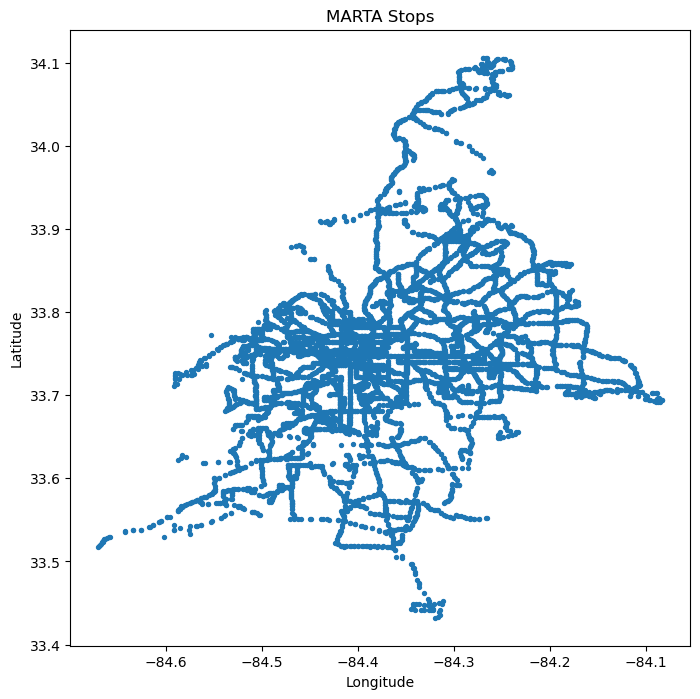

In [28]:
#Visualizing the stops to sanity check the coordinates and the KD-tree indexing
tree, stop_coords = build_stop_index(stops)
plt.figure(figsize=(8, 8))
plt.scatter(stops['stop_lon'], stops['stop_lat'], s=8)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("MARTA Stops")
plt.show()

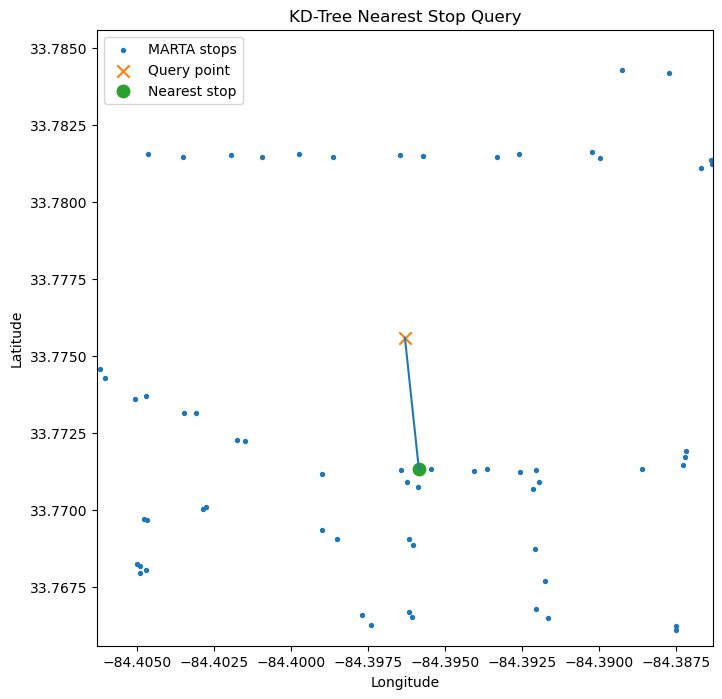

In [29]:
#Sanity check the KD-tree by querying a known point and visualizing the nearest stop
query_point = np.array([33.7756, -84.3963])  
#Query nearest stop
dist, idx = tree.query(query_point)
nearest_stop = stop_coords[idx]

plt.figure(figsize=(8, 8))
plt.scatter(stops['stop_lon'], stops['stop_lat'], s=8, label="MARTA stops")
plt.scatter(query_point[1], query_point[0], s=80, marker='x', label="Query point")
plt.scatter(nearest_stop[1], nearest_stop[0], s=80, marker='o', label="Nearest stop")

#Draw line from query point to nearest stop
plt.plot([query_point[1], nearest_stop[1]], [query_point[0], nearest_stop[0]])

lon_pad = 0.01
lat_pad = 0.01
plt.xlim(query_point[1] - lon_pad, query_point[1] + lon_pad)
plt.ylim(query_point[0] - lat_pad, query_point[0] + lat_pad)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KD-Tree Nearest Stop Query")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

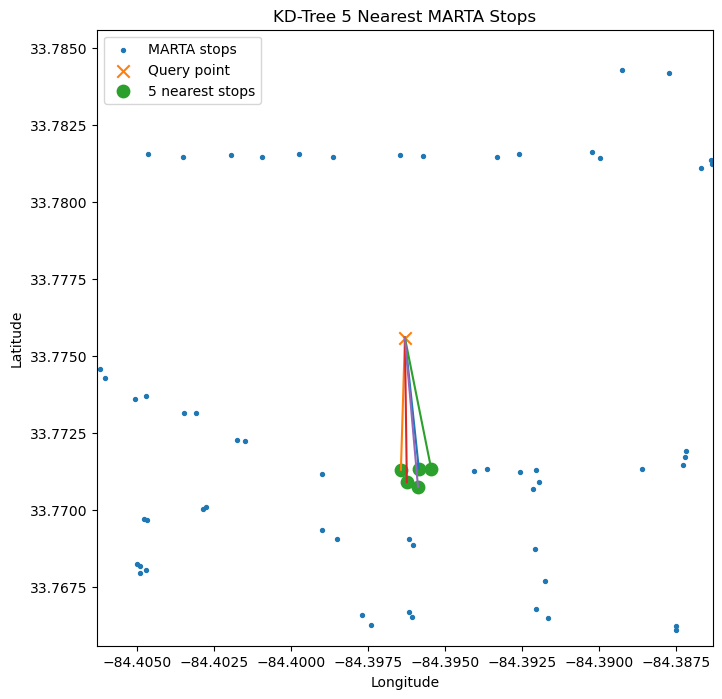

In [30]:
#Visualize the 5 nearest stops to the query point
k = 5
dists, indices = tree.query(query_point, k=k)
nearest_stops = stop_coords[indices]

plt.figure(figsize=(8, 8))
plt.scatter(stops['stop_lon'], stops['stop_lat'], s=8, label="MARTA stops")
plt.scatter(query_point[1], query_point[0], s=80, marker='x', label="Query point")
plt.scatter(nearest_stops[:, 1], nearest_stops[:, 0], s=80, label="5 nearest stops")

for stop in nearest_stops:
    plt.plot([query_point[1], stop[1]],[query_point[0], stop[0]])

# zoom window around query point
lon_pad = 0.01
lat_pad = 0.01
plt.xlim(query_point[1] - lon_pad, query_point[1] + lon_pad)
plt.ylim(query_point[0] - lat_pad, query_point[0] + lat_pad)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KD-Tree 5 Nearest MARTA Stops")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

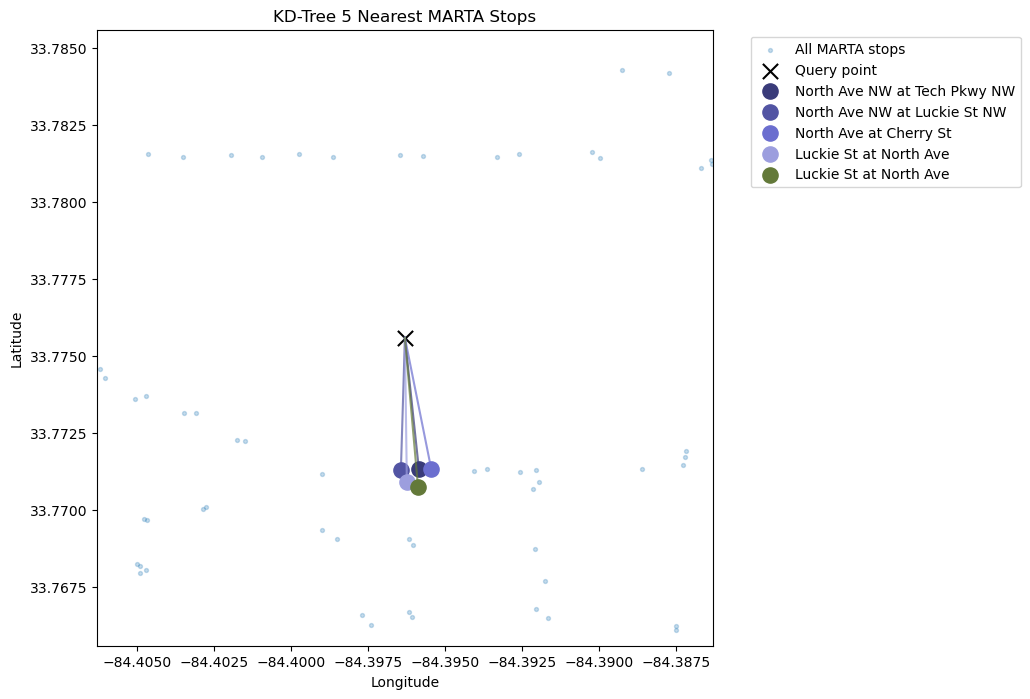

In [31]:
nearest_stops = stop_coords[indices]
plt.figure(figsize=(8,8))

#plot all stops
plt.scatter(stops['stop_lon'], stops['stop_lat'], s=8, alpha=0.25, label="All MARTA stops")
#plot query point
plt.scatter(query_point[1], query_point[0], s=120, marker='x', color='black', label="Query point")

#color palette
colors = plt.cm.tab20b.colors

for i, idx in enumerate(indices):
    row = stops.iloc[idx]
    stop = stop_coords[idx]
    plt.scatter(stop[1], stop[0], s=120, color=colors[i], label=row['stop_name'])
    plt.plot(
        [query_point[1], stop[1]],
        [query_point[0], stop[0]],
        color=colors[i],
        alpha=0.7)

# zoom window around query point
lon_pad = 0.01
lat_pad = 0.01
plt.xlim(query_point[1] - lon_pad, query_point[1] + lon_pad)
plt.ylim(query_point[0] - lat_pad, query_point[0] + lat_pad)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("KD-Tree 5 Nearest MARTA Stops")

#legend 
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Recurring Trip Detection
Uses DBSCAN on origin-destination coordinates and does not filter by trip purpose.
- Uses the **same `get_location_clusters` + `get_recurring_trips` functions**
  from `MatchingAlgorithm.ipynb` (DBSCAN, ε = 1 mile, min_samples = 2)
- **No purpose filter** — all trip types are eligible. A recurring leisure
  trip or errand is just as valid a transit candidate as a commute.
- Returns a representative (median) trip per OD cluster pair, used as the
  canonical departure time for the transit schedule search.

In [22]:
def get_location_clusters(trips, buffer_miles=DBSCAN_BUFFER_MILES,
                          min_samples=DBSCAN_MIN_SAMPLES):
    """
    Run DBSCAN separately on trip origins and destinations to assign
    each trip a start_cluster and end_cluster label.

    Trips labelled -1 by DBSCAN are spatial outliers — one-off trips
    to unusual locations — and are excluded from matching.

    Parameters
    buffer_miles : DBSCAN epsilon — two trips cluster together if their
                   origin (or destination) coordinates are within this
                   distance of each other
    min_samples  : minimum number of trips to form a cluster
    """
    trips = trips.copy()
    for col, lat_col, lon_col in [
        ('start_cluster', 'start_lat', 'start_lon'),
        ('end_cluster',   'end_lat',   'end_lon')
    ]:
        coords     = trips[[lat_col, lon_col]].values
        coords_rad = np.radians(coords)
        eps        = buffer_miles / 3958.8   #convert miles to radians
        labels = DBSCAN(
            eps=eps, min_samples=min_samples,
            algorithm='ball_tree', metric='haversine'
        ).fit_predict(coords_rad)
        trips[col] = labels
    return trips


def get_recurring_trips(trips, min_occurrences=DBSCAN_MIN_SAMPLES):
    """
    Filter trips to only those belonging to a recurring OD cluster pair.

    A trip is recurring if the same user makes a trip between the same
    origin cluster and destination cluster at least min_occurrences times.
    Outlier trips (DBSCAN label = -1) are always excluded.
    """
    trips = get_location_clusters(trips)

    # Drop outlier trips
    trips = trips[
        (trips['start_cluster'] != -1) &
        (trips['end_cluster']   != -1)
    ]

    # Count how many times each OD cluster pair appears
    od_counts = (
        trips
        .groupby(['start_cluster', 'end_cluster'])
        .size()
        .reset_index(name='occurrences')
    )

    recurring_od = od_counts[
        od_counts['occurrences'] >= min_occurrences
    ][['start_cluster', 'end_cluster', 'occurrences']]

    return trips.merge(recurring_od, on=['start_cluster', 'end_cluster'], how='inner')


def get_canonical_trip_for_od(recurring_trips, start_cluster, end_cluster):
    """
    From all recurring trips for a given OD cluster pair, return a single
    canonical representative trip.

    We use the median trip by start_time, which smooths out departure time
    jitter in the simulation (simulated.py adds ±5–15 min noise).
    The canonical trip's coordinates and departure time are used as the
    query input for the GTFS transit schedule search.
    """
    od_trips = recurring_trips[
        (recurring_trips['start_cluster'] == start_cluster) &
        (recurring_trips['end_cluster']   == end_cluster)
    ].sort_values('start_time')
    #median row 
    return od_trips.iloc[len(od_trips) // 2]   

sample_user_trips = user_trips[user_trips['user_id'] == 0]
sample_recurring = get_recurring_trips(sample_user_trips)
sample_od_pairs = sample_recurring[['start_cluster','end_cluster']].drop_duplicates()

print(f'User 0: {len(sample_recurring)} recurring trip instances')
print(f'across {len(sample_od_pairs)} distinct OD cluster pairs')
print(sample_od_pairs)

User 0: 33 recurring trip instances
across 2 distinct OD cluster pairs
   start_cluster  end_cluster
0              0            0
1              1            1


# Friendship Parsing 
The revised approach mirrors the carpool matching notebook exactly:
- Parse friendships into a bidirectional dict (same `parse_friendships` function)
- For each user's recurring trip, also check which **friends share the same
  recurring OD cluster**, so the transit suggestion is framed as something
  you and a friend can do together — consistent with deSOVer's social premise.

In [23]:
def parse_friendships(friendships_df):
    """
    Convert the friendships DataFrame into a bidirectional dict:
      { user_id: set of friend user_ids }

    The source CSV stores edges as (user_id_1, user_id_2) in one direction only.
    We make it bidirectional so lookups work from either end.
    """
    bidirectional = pd.concat([
        friendships_df.rename(columns={'user_id_1': 'user', 'user_id_2': 'friend'}),
        friendships_df.rename(columns={'user_id_2': 'user', 'user_id_1': 'friend'})
    ])
    return bidirectional.groupby('user')['friend'].apply(set).to_dict()

friendships_dict = parse_friendships(friendships)

total_edges = sum(len(v) for v in friendships_dict.values()) // 2
print(f'Social graph: {len(friendships_dict)} users, {total_edges} friendship edges')
print(f'Sample — User 0 friends: {friendships_dict.get(0, set())}')

Social graph: 35 users, 69 friendship edges
Sample — User 0 friends: {32, 17, 27, 25}


# Core Transit Matching Function

### Matching Logic
Given a trip's origin, destination, and typical departure time, it finds all MARTA routes that could serve that journey and scores them.

origin (lat, lon)                          
destination (lat, lon)                                          
origin_stops (within .33mi)               
dest_stops (within .33mi)

Find GTFS trips that serve BOTH stop sets:
- stop_times WHERE stop_id IN origin_stops →  get trip_ids
- stop_times WHERE trip_id IN those →  filter to dest_stops
- AND dest stop_sequence > origin stop_sequence (right direction)
- AND dep_min within ±TIME_WINDOW of user departure
                 
For each valid (trip_id, board_stop, alight_stop):
- walk_to_min   = walk_mi / WALK_SPEED_MI_H × 60
- ride_min      = alight_dep_min − board_dep_min
- walk_from_min = walk_mi_dest / WALK_SPEED_MI_H × 60
- total_min     = walk_to + ride + walk_from

In [24]:
def find_transit_options_for_trip(
        origin_lat, origin_lon, dest_lat, dest_lon,
        departure_time,
        tree, stops_df, stop_times_df, trips_df, calendar_df,
        top_n=TOP_N_TRANSIT, walk_radius_mi=WALK_RADIUS_MI,
        time_window_min=TIME_WINDOW_MINUTES):
    """
    Find viable MARTA transit alternatives for a single trip.
    Parameters
    ----------
    origin_lat/lon   : trip start coordinates
    dest_lat/lon     : trip end coordinates
    departure_time   : canonical departure datetime for this recurring trip
    tree             : pre-built KD-tree over MARTA stop coordinates
    stops_df         : stops DataFrame
    stop_times_df    : pre-processed stop_times (with dep_min column)
    trips_df         : GTFS trips DataFrame
    calendar_df      : GTFS calendar DataFrame
    top_n            : max results to return
    walk_radius_mi   : walk access radius in miles
    time_window_min  : ±minutes around departure_time to search

    Returns
    -------
    List of transit option dicts, sorted by score descending.
    """
    dep_mins    = departure_time.hour * 60 + departure_time.minute
    day_of_week = departure_time.weekday()

    #Find walkable stops at both ends
    origin_stops = stops_within_radius(origin_lat, origin_lon, tree, stops_df, walk_radius_mi)
    dest_stops   = stops_within_radius(dest_lat,   dest_lon,   tree, stops_df, walk_radius_mi)
    if origin_stops.empty or dest_stops.empty:
        return []

    origin_stop_ids = set(origin_stops['stop_id'].tolist())
    dest_stop_ids   = set(dest_stops['stop_id'].tolist())

    #Get active GTFS service IDs for this day
    active_service_ids = get_active_service_ids(calendar_df, day_of_week)
    active_trip_ids    = set()
    for svc_id in active_service_ids:
        active_trip_ids.update(service_to_trips.get(svc_id, set()))
    if not active_trip_ids:
        return []

    #Filter stop_times to active trips departing near origin within time window
    lower, upper = dep_mins - time_window_min, dep_mins + time_window_min
    origin_st = stop_times_df[
        (stop_times_df['trip_id'].isin(active_trip_ids)) &
        (stop_times_df['stop_id'].isin(origin_stop_ids)) &
        (stop_times_df['dep_min'] >= lower) &
        (stop_times_df['dep_min'] <= upper)
    ]
    if origin_st.empty:
        return []

    #Find destination stops served by the same trips, after the boarding stop
    candidate_trip_ids = set(origin_st['trip_id'].tolist())
    dest_st = stop_times_df[
        (stop_times_df['trip_id'].isin(candidate_trip_ids)) &
        (stop_times_df['stop_id'].isin(dest_stop_ids))
    ]
    if dest_st.empty:
        return []

    #Join board + deboard rows; enforce forward direction via stop_sequence
    pairs = origin_st[['trip_id','stop_id','stop_sequence','dep_min']].merge(
        dest_st[['trip_id','stop_id','stop_sequence','dep_min']],
        on='trip_id', suffixes=('_board','_deboard'))
    pairs = pairs[pairs['stop_sequence_deboard'] > pairs['stop_sequence_board']]
    if pairs.empty:
        return []

    trip_to_route = trips_df.set_index('trip_id')['route_id'].to_dict()
    results = []

    for _, row in pairs.iterrows():
        trip_id       = row['trip_id']
        board_stop_id = row['stop_id_board']
        deboard_stop_id = row['stop_id_deboard']
        board_dep_min   = row['dep_min_board']
        deboard_dep_min = row['dep_min_deboard']

        board_stop   = origin_stops[origin_stops['stop_id'] == board_stop_id]
        deboard_stop = dest_stops[dest_stops['stop_id'] == deboard_stop_id]
        if board_stop.empty or deboard_stop.empty:
            continue
        board_stop   = board_stop.iloc[0]
        deboard_stop = deboard_stop.iloc[0]

        walk_to_min   = (board_stop['walk_mi']   / WALK_SPEED_MI_H) * 60
        ride_min      = max(deboard_dep_min - board_dep_min, 0)
        walk_from_min = (deboard_stop['walk_mi'] / WALK_SPEED_MI_H) * 60
        total_min     = walk_to_min + ride_min + walk_from_min
        if total_min <= 0:
            continue

        dist_mi   = float(haversine_mi_vectorized([origin_lat],[origin_lon],dest_lat,dest_lon)[0])
        drive_min = (dist_mi * 1.3 / AVG_DRIVE_SPEED_MI_H) * 60
        time_ratio = total_min / max(drive_min, 1)

        time_delta    = abs(board_dep_min - dep_mins)
        schedule_fit  = 1.0 - (time_delta / time_window_min)
        walk_score    = 1.0 - min(board_stop['walk_mi'] / walk_radius_mi, 1.0)
        time_ratio_score = max(0.0, 1.0 - max(time_ratio - 1.0, 0.0))
        score = 0.45*schedule_fit + 0.30*walk_score + 0.25*time_ratio_score

        route_id   = trip_to_route.get(trip_id, '')
        rinfo      = route_info.get(route_id, {})
        route_type = rinfo.get('route_type_text', rinfo.get('route_type', 'Bus'))

        co2_drive   = dist_mi * 1.3 * CO2_DRIVE_LB_PER_MI
        co2_factor  = CO2_RAIL_LB_PER_MI if 'rail' in str(route_type).lower() else CO2_BUS_LB_PER_MI
        co2_transit = dist_mi * 1.0 * co2_factor
        co2_saved   = round(co2_drive - co2_transit, 3)

        results.append({
            'route_id':          route_id,
            'route_short_name':  rinfo.get('route_short_name', route_id),
            'route_long_name':   rinfo.get('route_long_name', ''),
            'route_type':        str(route_type),
            'route_color':       rinfo.get('route_color', '008000'),
            'board_stop_name':   board_stop['stop_name'],
            'board_stop_id':     board_stop_id,
            'deboard_stop_name': deboard_stop['stop_name'],
            'deboard_stop_id':   deboard_stop_id,
            'departure_time':    f"{board_dep_min//60:02d}:{board_dep_min%60:02d}",
            'arrival_time':      f"{deboard_dep_min//60:02d}:{deboard_dep_min%60:02d}",
            'time_delta_min':    round(time_delta, 1),
            'walk_to_stop_min':  round(walk_to_min, 1),
            'walk_to_stop_mi':   round(board_stop['walk_mi'], 3),
            'ride_min':          round(ride_min, 1),
            'walk_from_stop_min':round(walk_from_min, 1),
            'walk_from_stop_mi': round(deboard_stop['walk_mi'], 3),
            'total_min':         round(total_min, 1),
            'drive_min_estimate':round(drive_min, 1),
            'time_vs_driving':   f"+{round(total_min-drive_min,0):.0f} min"
                                 if total_min > drive_min
                                 else f"{round(total_min-drive_min,0):.0f} min (faster!)",
            'co2_saved_lbs':     round(co2_saved * 2.205, 2),
            'score':             round(score, 4),
            'schedule_fit':      round(schedule_fit, 4),
            'walk_score':        round(walk_score, 4),
            'time_ratio':        round(time_ratio, 3),
        })

    if not results:
        return []

    #Deduplicate: keep best-scoring departure per route line
    seen_routes = {}
    for r in sorted(results, key=lambda x: x['score'], reverse=True):
        key = r['route_short_name']
        if key not in seen_routes:
            seen_routes[key] = r
    return list(seen_routes.values())[:top_n]

print('Core transit matching function defined.')

Core transit matching function defined.


# Social-Aware Transit Suggestions

The original `get_transit_suggestions_for_user` found transit options for
a single user's trips in isolation. The revised version:

1. Uses **DBSCAN-based recurring trip detection** (same as carpool matching)
   instead of the dep_bucket / purpose-filter approach
2. Checks **which friends share the same recurring OD cluster pair** —
   the same social filter logic used in the carpool engine
3. Attaches the matched friend(s) to each transit suggestion so the
   recommendation can be framed as 'take the bus with Alex' rather than
   just 'there is a bus'


In [25]:
def get_transit_suggestions_for_user(user_id: int,
                                      all_trips: pd.DataFrame,
                                      friendships_dict: dict) -> list:
    """
    Find MARTA transit alternatives for a user's recurring trips,
    and identify which friends share each recurring OD pattern.

    REVISED from original: now uses DBSCAN recurring trip detection
    (consistent with MatchingAlgorithm.ipynb) and adds friend matching.

    Parameters
    ----------
    user_id          : the user to find suggestions for
    all_trips        : the full trips DataFrame (all users)
    friendships_dict : bidirectional friend lookup dict from parse_friendships()

    Returns
    -------
    List of suggestion dicts. Each dict contains all transit option fields
    from find_transit_options_for_trip() plus:
      - 'pattern_label'     : human-readable OD cluster pair label
      - 'user_trip_id'      : trip_id of the canonical trip used
      - 'user_id'           : the queried user
      - 'friends_on_route'  : list of friend user_ids who share this
                              recurring OD pattern (may be empty)
    """
    #Step 1: Get this user's recurring trips via DBSCAN 
    my_trips = all_trips[all_trips['user_id'] == user_id]
    my_recurring = get_recurring_trips(my_trips)

    if my_recurring.empty:
        print(f'User {user_id}: no recurring trips found.')
        return []

    #Get the distinct OD cluster pairs this user travels recurringly
    my_od_pairs = my_recurring[['start_cluster', 'end_cluster']].drop_duplicates()

    #Step 2: Get this user's direct friends
    my_friends = friendships_dict.get(user_id, set())

    all_suggestions = []

    #Step 3: For each recurring OD pair, find transit + matching friends 
    for _, od in my_od_pairs.iterrows():
        sc = od['start_cluster']
        ec = od['end_cluster']

        #Get the canonical (median) trip for this OD pair
        canonical = get_canonical_trip_for_od(my_recurring, sc, ec)
        pattern_label = f'OD({sc}→{ec})'

        #Step 3a: Find friends who share this OD cluster pair 
        # A friend 'shares' the pattern if they also have recurring trips in
        # the same start_cluster AND end_cluster. This is the same logic used
        # in the carpool matching notebook to identify compatible trip pairs.
        friends_on_route = []
        for friend_id in my_friends:
            friend_trips    = all_trips[all_trips['user_id'] == friend_id]
            friend_recurring = get_recurring_trips(friend_trips)
            if friend_recurring.empty:
                continue
            # Check if this friend has the same OD cluster pair
            friend_od = friend_recurring[['start_cluster','end_cluster']].drop_duplicates()
            match = friend_od[
                (friend_od['start_cluster'] == sc) &
                (friend_od['end_cluster']   == ec)
            ]
            if not match.empty:
                friends_on_route.append(int(friend_id))

        #Step 3b: Find MARTA options for this canonical trip
        options = find_transit_options_for_trip(
            origin_lat     = canonical['start_lat'],
            origin_lon     = canonical['start_lon'],
            dest_lat       = canonical['end_lat'],
            dest_lon       = canonical['end_lon'],
            departure_time = canonical['start_time'],
            tree           = stop_tree,
            stops_df       = stops,
            stop_times_df  = stop_times,
            trips_df       = trips,
            calendar_df    = calendar
        )

        #Attach metadata to each option and collect
        for opt in options:
            opt['pattern_label'] = pattern_label
            opt['user_trip_id'] = int(canonical['trip_id'])
            opt['user_id'] = user_id
            opt['friends_on_route'] = friends_on_route
            all_suggestions.append(opt)

    return all_suggestions

print('deSOVer transit suggestion function defined.')

deSOVer transit suggestion function defined.


# Run & Inspect Results

In [35]:
TARGET_USER = 18
print(f'Finding transit suggestions for User {TARGET_USER}...\n')

suggestions = get_transit_suggestions_for_user(
    user_id  = TARGET_USER,
    all_trips  = user_trips,
    friendships_dict = friendships_dict)

if not suggestions:
    print('No transit options found.')
    print('Common reasons:')
    print('  • No MARTA stops within WALK_RADIUS_MI of this user\'s recurring locations')
    print('  • GTFS service doesn\'t run on the relevant days')
    print('  • Try increasing WALK_RADIUS_MI or TIME_WINDOW_MINUTES')
else:
    print(f'Found {len(suggestions)} transit suggestion(s):\n')
    for i, s in enumerate(suggestions, 1):
        friends_str = ', '.join(f'User {f}' for f in s['friends_on_route']) or 'none'
        print(f'  #{i}  Route {s["route_short_name"]} — {s["route_long_name"]}')
        print(f'       Type: {s["route_type"]}  |  Pattern: {s["pattern_label"]}')
        print(f'       Board  : {s["board_stop_name"]} at {s["departure_time"]}')
        print(f'       Deboard: {s["deboard_stop_name"]} at {s["arrival_time"]}')
        print(f'       Journey: walk {s["walk_to_stop_min"]}min → '
              f'ride {s["ride_min"]}min → '
              f'walk {s["walk_from_stop_min"]}min = '
              f'{s["total_min"]}min total')
        print(f'       vs. driving: {s["time_vs_driving"]}  |  '
              f'CO\u2082 saved: {s["co2_saved_lbs"]} lbs')
        print(f'       Score: {s["score"]} '
              f'(sched={s["schedule_fit"]:.2f}, '
              f'walk={s["walk_score"]:.2f}, '
              f'time_ratio={s["time_ratio"]:.2f})')
        print(f'       Friends also on this route: {friends_str}')
        print()

Finding transit suggestions for User 18...

Found 1 transit suggestion(s):

  #1  Route 110 — Peachtree Road / Buckhead
       Type: 3  |  Pattern: OD(0→0)
       Board  : Peachtree Rd NE at Stratford Rd NE at 07:01
       Deboard: Peachtree Rd NW at W Shadowlawn Ave at 07:05
       Journey: walk 5.7min → ride 4min → walk 6.6min = 16.3min total
       vs. driving: +13 min  |  CO₂ saved: 1.58 lbs
       Score: 0.431 (sched=0.87, walk=0.14, time_ratio=4.36)
       Friends also on this route: User 1, User 5, User 8, User 14, User 16, User 19, User 31



In [27]:
#Run for all users and collect results into a single DataFrame
all_transit_suggestions = []

for uid in sorted(user_trips['user_id'].unique()):
    uid = int(uid)
    user_suggestions = get_transit_suggestions_for_user(
        user_id          = uid,
        all_trips        = user_trips,
        friendships_dict = friendships_dict
    )
    if user_suggestions:
        print(f'  User {uid:>2}: {len(user_suggestions)} suggestion(s) — '
              f'top route: {user_suggestions[0]["route_short_name"]}')
    else:
        print(f'  User {uid:>2}: no transit options found')
    all_transit_suggestions.extend(user_suggestions)

if all_transit_suggestions:
    df_transit = pd.DataFrame(all_transit_suggestions)
    print(f'\nTotal suggestions: {len(df_transit)}')
    print(f'Users with options: {df_transit["user_id"].nunique()}')
    print(f'Most common routes:')
    print(df_transit['route_short_name'].value_counts().head(10))
    print(f'\nSuggestions with at least one friend on route: '
          f'{df_transit["friends_on_route"].apply(len).gt(0).sum()}')
    print(f'Avg CO\u2082 saved per suggestion: '
          f'{df_transit["co2_saved_lbs"].mean():.2f} lbs')

  User  0: no transit options found
  User  1: 1 suggestion(s) — top route: 26
  User  2: no transit options found
  User  3: no transit options found
  User  4: no transit options found
  User  5: no transit options found
  User  6: no transit options found
  User  7: no transit options found
  User  8: no transit options found
  User  9: no transit options found
  User 10: no transit options found
  User 11: no transit options found
  User 12: no transit options found
  User 13: no transit options found
  User 14: no transit options found
  User 15: no transit options found
  User 16: no transit options found
  User 17: no transit options found
  User 18: 1 suggestion(s) — top route: 110
  User 19: no transit options found
  User 20: no transit options found
  User 21: no transit options found
  User 22: no transit options found
  User 23: no transit options found
  User 24: no transit options found
  User 25: no transit options found
  User 26: no transit options found
  User 27: no

# Messing Around W/ Thresholds

In [33]:
## TESTING ON USER 0's RECURRRING TRIPS MANUALLY TO SEE IF THEY ACTUALLY DONT HAVE ANY TRANSIT RECS
# User 0 has 4 recurring commute pattern(s):
# Tue @ 07:00:00  origin=(33.8960,-84.4636)  dest=(33.7866,-84.3887)  3x
# Thu @ 17:30:00  origin=(33.7866,-84.3887)  dest=(33.8960,-84.4636)  3x
# Fri @ 07:00:00  origin=(33.8960,-84.4636)  dest=(33.7866,-84.3887)  3x
# Fri @ 18:00:00  origin=(33.7866,-84.3887)  dest=(33.8960,-84.4636)  3x

# Tue @ 07:00:00  origin=(33.8960,-84.4636)  dest=(33.7866,-84.3887)  3x
# Trip from Midtown to Cumberland (probably work)
print(find_transit_options_for_trip(origin_lat=33.8960, origin_lon=-84.4636,
        dest_lat=33.7866, dest_lon=-84.3887,
        departure_time=datetime(2024, 1, 2, 7, 0),  # Tuesday at 7:00 AM
        tree=stop_tree,
        stops_df=stops,
        stop_times_df=stop_times,
        trips_df=trips,
        calendar_df=calendar,
        top_n=TOP_N_TRANSIT,
        walk_radius_mi=WALK_RADIUS_MI,
        time_window_min=TIME_WINDOW_MINUTES))

# Fri @ 07:00:00  origin=(33.8960,-84.4636)  dest=(33.7866,-84.3887)  3x
# Trip from Midtown to Cumberland (probably work)
print(find_transit_options_for_trip(origin_lat=33.8960, origin_lon=-84.4636,
        dest_lat=33.7866, dest_lon=-84.3887,
        departure_time=datetime(2024, 4, 2, 7, 30),  # Friday at 7:00am
        tree=stop_tree,
        stops_df=stops,
        stop_times_df=stop_times,
        trips_df=trips,
        calendar_df=calendar,
        top_n=TOP_N_TRANSIT,
        walk_radius_mi=WALK_RADIUS_MI,
        time_window_min=TIME_WINDOW_MINUTES))

# Thu @ 17:30:00  origin=(33.7866,-84.3887)  dest=(33.8960,-84.4636)  3x
# Trip from Midtown to Cumberland (probably work)
print(find_transit_options_for_trip(origin_lat=33.7866, origin_lon=-84.3887,
        dest_lat=33.8960, dest_lon=-84.4636,
        departure_time=datetime(2024, 1, 4, 17, 30),  # Thursday at 5:30 PM
        tree=stop_tree,
        stops_df=stops,
        stop_times_df=stop_times,                       
        trips_df=trips,
        calendar_df=calendar,
        top_n=TOP_N_TRANSIT,
        walk_radius_mi=WALK_RADIUS_MI,
        time_window_min=TIME_WINDOW_MINUTES))   

# Fri @ 18:00:00  origin=(33.7866,-84.3887)  dest=(33.8960,-84.4636)  3x
# Trip from Midtown to Cumberland (probably work)
print(find_transit_options_for_trip(origin_lat=33.7866, origin_lon=-84.3887,
        dest_lat=33.8960, dest_lon=-84.4636,
        departure_time=datetime(2024, 1, 5, 18, 0),  # Friday at 6:00 PM
        tree=stop_tree,
        stops_df=stops,
        stop_times_df=stop_times,               
        trips_df=trips,
        calendar_df=calendar,
        top_n=TOP_N_TRANSIT,
        walk_radius_mi=WALK_RADIUS_MI,
        time_window_min=TIME_WINDOW_MINUTES))

# Try Fri 18:00 with a wider mile radius - makes sense bc its a trip from Midtown to Cumberland 
print(find_transit_options_for_trip(origin_lat=33.7866, origin_lon=-84.3887,
        dest_lat=33.8960, dest_lon=-84.4636,
        departure_time=datetime(2024, 1, 5, 18, 0),  # Friday at 6:00 PM
        tree=stop_tree,
        stops_df=stops,
        stop_times_df=stop_times,               
        trips_df=trips,
        calendar_df=calendar,
        top_n=TOP_N_TRANSIT,
        walk_radius_mi=1.5,
        time_window_min=TIME_WINDOW_MINUTES))


[]
[]
[]
[]
[{'route_id': 18641, 'route_short_name': '12', 'route_long_name': 'Howell Mill Road / Cumberland', 'route_type': '3', 'route_color': 'FF00FF', 'board_stop_name': 'Midtown Station', 'board_stop_id': np.int64(81910), 'deboard_stop_name': 'Cobb Pkwy SE at Parkway Pointe SE', 'deboard_stop_id': np.int64(99970093), 'departure_time': '18:00', 'arrival_time': '18:49', 'time_delta_min': np.int64(0), 'walk_to_stop_min': np.float64(7.9), 'walk_to_stop_mi': np.float64(0.396), 'ride_min': np.int64(49), 'walk_from_stop_min': np.float64(26.1), 'walk_from_stop_mi': np.float64(1.303), 'total_min': np.float64(83.0), 'drive_min_estimate': 29.5, 'time_vs_driving': '+54 min', 'co2_saved_lbs': 12.52, 'score': np.float64(0.6707), 'schedule_fit': np.float64(1.0), 'walk_score': np.float64(0.7357), 'time_ratio': np.float64(2.814)}]
